## Machine Learning-Based Prediction of Greenhouse Crop Yields Using IoT Sensor Data

### 1. Introduction: Main question, why it matters and how we are going to answer it

Agriculture is increasingly being transformed by technology, and greenhouse farming sits at the centre of this transformation. Unlike open-field farming, greenhouses offer the ability to monitor and control environmental conditions in real time through IoT (Internet of Things) sensors that continuously record temperature, humidity, CO₂ levels, light intensity, soil pH, and fertilizer inputs. Despite the abundance of this data, many farming operations still rely on experience-based judgment to estimate how much yield a crop will produce — a method that is often inaccurate and costly.

This project addresses that gap by asking: **Can we accurately predict greenhouse crop yield using IoT sensor and environmental data, and which machine learning model does this best?**

Accurate yield prediction matters for several practical reasons. Farmers and agribusinesses can use it to plan harvests, reduce waste, and optimise resource use such as water, fertilizer, and energy. For food security planning, reliable yield estimates help institutions and governments anticipate supply. And for the growing AgriTech industry, predictive models represent a core component of smart farming systems.

To answer the research question, this project applies three supervised machine learning regression models — Linear Regression, Random Forest, and XGBoost — to a dataset of over 10,000 greenhouse crop records collected via IoT sensors. The models are compared using standard regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The best-performing model is identified and its key predictive features are examined to draw practical insights for smart agriculture.

**Main question: Can greenhouse crop yield be accurately predicted from IoT sensor data, and which machine learning model performs best?**

### 2. Dataset Description

**Name:** Greenhouse Crop Yields (IoT & AgriTech)

**Source / Citation:**  
Kaggle (2024). *Greenhouse Crop Yields (IoT & AgriTech)* [Dataset]. Kaggle. Retrieved from https://https//www.kaggle.com/datasets/moezalikhan/greenhouse-crop-yields-dataset

**Format:** CSV  
**Records / Columns:** 10,400 / 20

**Description:**  
This dataset contains IoT sensor readings and agronomic records from greenhouse crop production environments. Each record represents a single crop growing cycle, capturing environmental conditions (temperature, humidity, CO₂, light), resource inputs (irrigation, fertilizer), soil properties (pH), pest pressure, and the resulting crop yield in kg per m². Four crop types are represented: Tomato, Cucumber, Lettuce, and Pepper.

**Input Features:**
- `avg_temperature_C`, `min_temperature_C`, `max_temperature_C` — daily temperature readings (°C)
- `humidity_percent` — relative humidity (%)
- `co2_ppm` — CO₂ concentration (parts per million)
- `light_intensity_lux` — light intensity (lux)
- `photoperiod_hours` — daily light hours
- `irrigation_mm` — water applied (mm)
- `fertilizer_N_kg_ha`, `fertilizer_P_kg_ha`, `fertilizer_K_kg_ha` — NPK fertilizer inputs
- `pest_severity` — pest pressure index
- `soil_pH` — soil acidity/alkalinity
- `days_to_maturity` — crop growth duration (days)
- `crop_type` — categorical crop label

**Target Variable:**
- `yield_kg_per_m2` — crop yield in kilograms per square metre

### 3. Exploratory Data Analysis, Preprocessing & Statistical Analysis

We begin by importing all the Python libraries needed for this project. `pandas` and `numpy` handle data loading and manipulation. `seaborn` and `matplotlib` are used for all visualizations. `scipy.stats` provides the statistical tests. From `sklearn` we import tools for scaling, model building, and evaluation. `xgboost` provides the XGBoost regression algorithm. Finally, we create a `plots/` folder to save all generated figures.

In [1]:
# Importing necessary libraries

# For data handling
import pandas as pd
import numpy as np

# For visualization
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# For statistical tests
from scipy.stats import levene, f_oneway

# For machine learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import os
os.makedirs("plots", exist_ok=True)

This loads the dataset from GitHub into a pandas DataFrame. We then print the shape to confirm it loaded correctly and display the first five rows to get a feel for what the data looks like.

In [2]:
import pandas as pd

# Dataset loaded directly from GitHub
url = 'https://raw.githubusercontent.com/muganzibaker/greenhouse-ml-project/main/greenhouse_crop_yields.csv'
df = pd.read_csv(url)

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (10400, 20)

First 5 rows:


,greenhouse_id,crop_type,variety,planting_date,harvest_date,days_to_maturity,avg_temperature_C,min_temperature_C,max_temperature_C,humidity_percent,co2_ppm,light_intensity_lux,photoperiod_hours,irrigation_mm,fertilizer_N_kg_ha,fertilizer_P_kg_ha,fertilizer_K_kg_ha,pest_severity,soil_pH,yield_kg_per_m2
0,1.0,Tomato,Beefsteak,2023-11-02,2024-01-08,67.0,27.6,25.8,30.6,73.6,917.0,16821.0,10.0,9.8,167.0,74.0,154.0,1.3,6.1,9.19
1,3.0,Cucumber,English,2023-11-01,2024-01-03,63.0,24.4,21.0,27.3,80.8,782.0,27483.0,10.0,9.2,174.0,82.0,126.0,3.2,6.3,7.42
2,5.0,Tomato,Beefsteak,2023-02-02,2023-04-19,76.0,23.9,20.6,26.0,76.6,821.0,30516.0,10.0,7.0,234.0,64.0,243.0,1.2,6.0,20.86
3,5.0,Tomato,Heirloom,2023-07-29,2023-10-21,84.0,26.7,25.5,29.6,76.1,710.0,43580.0,15.1,5.4,167.0,63.0,234.0,0.8,6.0,22.09
4,4.0,Cucumber,Slicing,2023-02-07,2023-04-15,67.0,24.1,22.4,26.5,69.8,921.0,22283.0,10.0,8.4,102.0,98.0,173.0,1.1,7.4,6.42


We inspect the data types of each column and check for any non-null counts. This tells us which columns are numeric, which are categorical (like `crop_type`), and gives an early indication of where missing values exist.

In [3]:
# Data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   greenhouse_id        10400 non-null  float64
 1   crop_type            10400 non-null  object 
 2   variety              10400 non-null  object 
 3   planting_date        10400 non-null  object 
 4   harvest_date         10400 non-null  object 
 5   days_to_maturity     10400 non-null  float64
 6   avg_temperature_C    9858 non-null   float64
 7   min_temperature_C    9858 non-null   float64
 8   max_temperature_C    9858 non-null   float64
 9   humidity_percent     9858 non-null   float64
 10  co2_ppm              9827 non-null   float64
 11  light_intensity_lux  9858 non-null   float64
 12  photoperiod_hours    10400 non-null  float64
 13  irrigation_mm        10400 non-null  float64
 14  fertilizer_N_kg_ha   9342 non-null   float64
 15  fertilizer_P_kg_ha   9342 non-null  

Before any analysis, we check for duplicate rows — records that are identical across all columns. Duplicates can inflate model performance and skew statistics, so they must be identified. We also look at the distribution of the `crop_type` column to understand how balanced the dataset is across the four crop categories: Tomato, Cucumber, Lettuce, and Pepper.

In [4]:
# Check for duplicate rows
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)

# Crop type distribution
print("\nCrop type distribution:")
print(df['crop_type'].value_counts())

Number of duplicate rows: 200

Crop type distribution:
crop_type
Tomato      4112
Cucumber    3167
Lettuce     2069
Pepper      1052
Name: count, dtype: int64


Descriptive statistics give us a numerical summary of each feature — including the mean, standard deviation, minimum, maximum, and quartile values. We also append a missing value count and percentage for each column, so we can clearly see which features need cleaning before modelling.

In [5]:
# Descriptive statistics with missing value summary
numeric_features = [
    'avg_temperature_C', 'humidity_percent', 'co2_ppm',
    'light_intensity_lux', 'irrigation_mm', 'fertilizer_N_kg_ha',
    'fertilizer_K_kg_ha', 'pest_severity', 'soil_pH',
    'days_to_maturity', 'yield_kg_per_m2'
]

desc = df[numeric_features].describe().T
desc['Missing Count'] = df[numeric_features].isnull().sum()
desc['Missing (%)'] = (df[numeric_features].isnull().sum() / len(df)) * 100
desc

,count,mean,std,min,25%,50%,75%,max,Missing Count,Missing (%)
avg_temperature_C,9858.0,23.421627,3.401036,10.6,21.7000,24.100,25.80,32.00,542,5.211538
humidity_percent,9858.0,74.972327,8.582842,47.2,68.9000,75.000,81.20,100.00,542,5.211538
co2_ppm,9827.0,799.832095,148.809930,348.0,698.0000,800.000,903.00,1200.00,573,5.509615
light_intensity_lux,9858.0,30045.450193,8086.985394,5000.0,24016.7500,30106.500,36075.75,57094.00,542,5.211538
irrigation_mm,10400.0,7.003212,1.982951,1.0,5.6000,7.000,8.40,13.50,0,0.000000
fertilizer_N_kg_ha,9342.0,163.441661,42.012956,80.0,130.0000,163.000,194.00,250.00,1058,10.173077
fertilizer_K_kg_ha,9342.0,166.801006,39.775813,80.0,137.0000,167.000,194.00,250.00,1058,10.173077
pest_severity,10276.0,1.831666,1.448331,-0.2,0.6000,1.600,2.80,6.70,124,1.192308
soil_pH,10098.0,6.505070,0.500929,5.0,6.2000,6.500,6.80,8.00,302,2.903846
days_to_maturity,10400.0,64.519327,16.392426,29.0,53.0000,65.000,77.00,100.00,0,0.000000


#### 3.1 Data Cleaning and Preprocessing

**Data Cleaning Steps:**

1. **Label Encoding:** The `crop_type` column is categorical (text). Machine learning models require numeric inputs, so we use `LabelEncoder` to convert Cucumber, Lettuce, Pepper, and Tomato into integer codes.

2. **Outlier Handling:** The `pest_severity` column contains negative values, which are physically impossible (pest severity cannot be negative). These are treated as data entry errors and clipped to zero.

3. **Feature Selection:** `min_temperature_C` and `max_temperature_C` are excluded from modelling features. Since `avg_temperature_C` already captures the central thermal condition per growing cycle, including min/max introduces multicollinearity — particularly in Linear Regression. The average alone is the most informative and least redundant temperature feature.

4. **Missing Value Imputation:** Several columns — including temperature readings and fertilizer inputs — contain missing values. We fill these with each column's **median** value, which is more robust to outliers than the mean and preserves the natural distribution of the data.

In [6]:
# Define features to use in modelling
features = [
    'avg_temperature_C',
    'humidity_percent', 'co2_ppm', 'light_intensity_lux',
    'photoperiod_hours', 'irrigation_mm', 'fertilizer_N_kg_ha',
    'fertilizer_P_kg_ha', 'fertilizer_K_kg_ha', 'pest_severity',
    'soil_pH', 'days_to_maturity', 'crop_type_enc'
]

# Encode crop_type as a numeric variable
le = LabelEncoder()
df['crop_type_enc'] = le.fit_transform(df['crop_type'])
print("Crop type encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Handle outliers: cap pest_severity at 0 (negative values are data entry errors)
df['pest_severity'] = df['pest_severity'].clip(lower=0)

# Fill missing values with column median (robust to outliers)
X = df[features].copy()
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].median())
        print(f"Filled missing values in '{col}' with median")

y = df['yield_kg_per_m2']

print("\nMissing values after cleaning:", X.isnull().sum().sum())

Crop type encoding: {'Cucumber': np.int64(0), 'Lettuce': np.int64(1), 'Pepper': np.int64(2), 'Tomato': np.int64(3)}
Filled missing values in 'avg_temperature_C' with median
Filled missing values in 'humidity_percent' with median
Filled missing values in 'co2_ppm' with median
Filled missing values in 'light_intensity_lux' with median
Filled missing values in 'fertilizer_N_kg_ha' with median
Filled missing values in 'fertilizer_P_kg_ha' with median
Filled missing values in 'fertilizer_K_kg_ha' with median
Filled missing values in 'pest_severity' with median
Filled missing values in 'soil_pH' with median

Missing values after cleaning: 0


#### 3.2 Visualizations

We now explore the data visually. Good visualizations help us understand the distribution of the target variable, how different crop types compare in yield, which features are most correlated with yield, and whether any obvious patterns or anomalies exist in the data.

**Figure 1 — Distribution of Crop Yield:**  
This histogram shows how yield values (kg/m²) are distributed across all records. The KDE (kernel density estimate) curve overlaid on the histogram gives a smooth estimate of the distribution shape. A roughly bell-shaped or right-skewed distribution is typical for agricultural yield data.

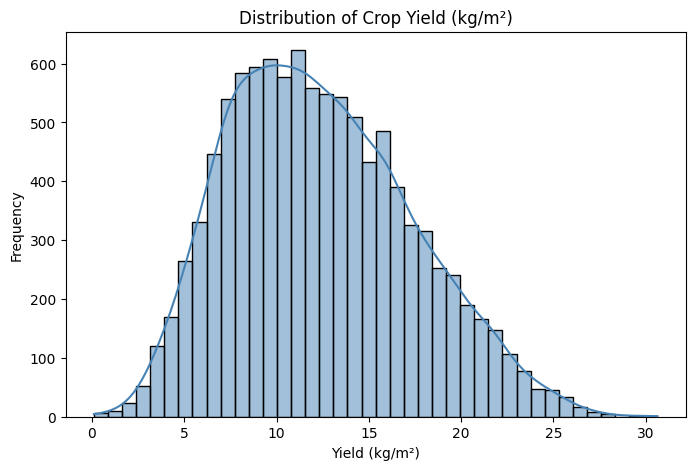

In [7]:
# Distribution of target variable: Crop Yield
plt.figure(figsize=(8, 5))
sns.histplot(df['yield_kg_per_m2'], bins=40, kde=True, color='steelblue')
plt.xlabel("Yield (kg/m\u00b2)")
plt.ylabel("Frequency")
plt.title("Distribution of Crop Yield (kg/m\u00b2)")
plt.savefig("plots/yield_distribution.png", dpi=300)
plt.show()

**Figure 2 — Yield by Crop Type:**  
This boxplot compares the yield distribution across the four crop types. Each box shows the interquartile range (25th to 75th percentile), the line inside is the median, and dots beyond the whiskers represent outliers. Differences in median yield across crop types indicate that crop type is likely an important predictor.

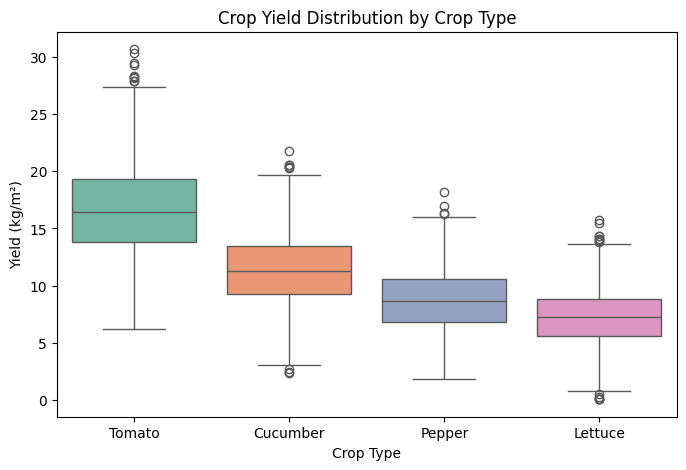

In [8]:
# Yield by crop type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='crop_type', y='yield_kg_per_m2', palette='Set2')
plt.xlabel("Crop Type")
plt.ylabel("Yield (kg/m\u00b2)")
plt.title("Crop Yield Distribution by Crop Type")
plt.savefig("plots/yield_by_crop_type.png", dpi=300)
plt.show()

**Figure 3 — Correlation Heatmap:**  
The heatmap shows the Pearson correlation coefficient between every pair of numeric features. Values close to **+1** indicate a strong positive relationship, values close to **-1** indicate a strong negative relationship, and values near **0** indicate little to no linear relationship. The last row/column (yield_kg_per_m2) is most relevant — it shows which features are most linearly correlated with our target variable.

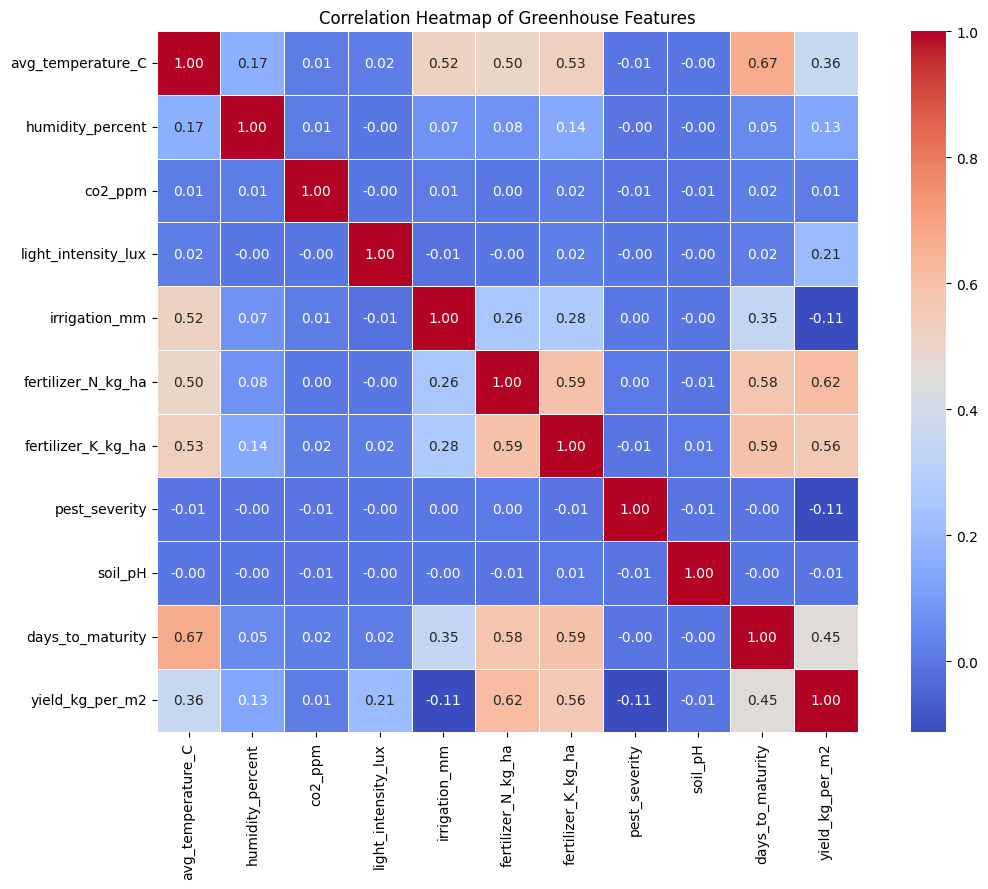

In [9]:
# Correlation heatmap
corr_cols = [
    'avg_temperature_C', 'humidity_percent', 'co2_ppm',
    'light_intensity_lux', 'irrigation_mm', 'fertilizer_N_kg_ha',
    'fertilizer_K_kg_ha', 'pest_severity', 'soil_pH',
    'days_to_maturity', 'yield_kg_per_m2'
]

plt.figure(figsize=(12, 9))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    square=True, linewidths=0.5
)
plt.title("Correlation Heatmap of Greenhouse Features")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=300)
plt.show()

**Figure 4 — Scatter Plots of Key Features vs Yield:**  
We plot the four features most correlated with yield individually against the target variable. Each point represents one crop growing cycle. A clear upward or downward trend in these plots confirms a meaningful linear or non-linear relationship between the feature and yield.

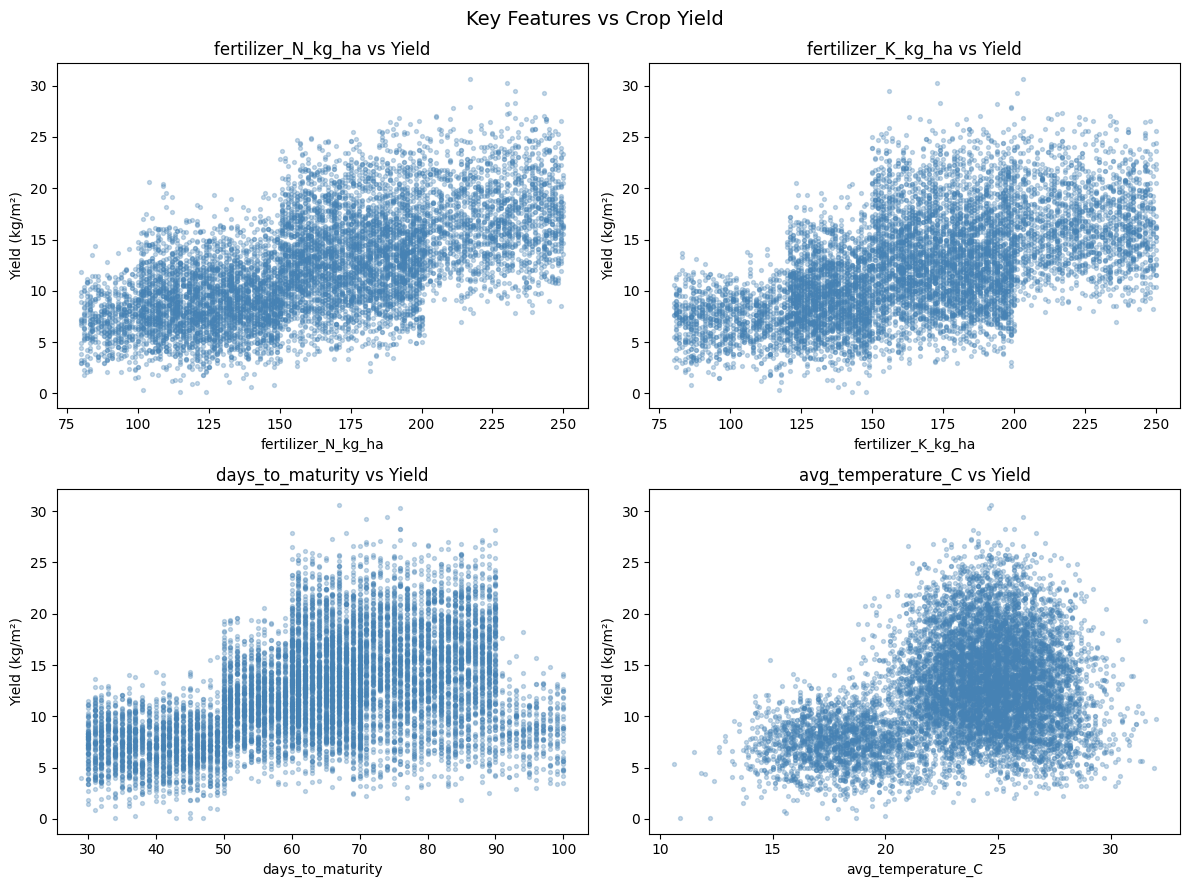

In [10]:
# Scatter plots: top correlated features vs yield
top_features = ['fertilizer_N_kg_ha', 'fertilizer_K_kg_ha', 'days_to_maturity', 'avg_temperature_C']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['yield_kg_per_m2'], alpha=0.3, color='steelblue', s=8)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Yield (kg/m\u00b2)")
    axes[i].set_title(f"{feat} vs Yield")

plt.suptitle("Key Features vs Crop Yield", fontsize=14)
plt.tight_layout()
plt.savefig("plots/scatter_features_vs_yield.png", dpi=300)
plt.show()

#### 3.3 Statistical Analysis

Beyond visualizations, we apply formal statistical tests to confirm whether the patterns we observe are statistically significant or could be due to random chance. We use a **One-Way ANOVA** to test for yield differences across crop types, and **Levene's Test** to check whether yield variability is consistent across crop types.

**One-Way ANOVA (Analysis of Variance):**  
ANOVA tests whether the **mean yield** differs significantly across the four crop types.  
- **Null hypothesis (H₀):** Mean yield is equal across all crop types  
- **Alternative hypothesis (H₁):** At least one crop type has a significantly different mean yield  
- If the **p-value < 0.05**, we reject H₀ and conclude that crop type significantly affects yield.

In [11]:
# One-way ANOVA: Does mean yield differ significantly across crop types?
# Null hypothesis: mean yield is equal across all crop types

groups = [df[df['crop_type'] == crop]['yield_kg_per_m2'].dropna()
          for crop in df['crop_type'].unique()]

f_stat, p_value = f_oneway(*groups)

print("One-Way ANOVA: Crop Yield across Crop Types")
print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: The difference in mean yield across crop types is statistically significant (p < 0.05).")
    print("This confirms that crop type is a meaningful predictor of yield.")
else:
    print("\nResult: No statistically significant difference in mean yield across crop types (p >= 0.05).")

One-Way ANOVA: Crop Yield across Crop Types
F-statistic : 4632.4482
p-value     : 0.000000

Result: The difference in mean yield across crop types is statistically significant (p < 0.05).
This confirms that crop type is a meaningful predictor of yield.


**Levene's Test for Equality of Variance:**  
While ANOVA tests differences in means, Levene's test checks whether the **spread (variance)** of yield is consistent across crop types.  
- **Null hypothesis (H₀):** Yield variance is equal across all crop types  
- If **p-value < 0.05**, the variance differs significantly — meaning some crops produce more consistent yields than others.  
This is important context for interpreting model predictions per crop type.

In [12]:
# Levene's test: equality of variance in yield across crop types
# Null hypothesis: variances are equal across crop types

lev_stat, lev_p = levene(*groups)

print("Levene's Test: Equality of Variance in Yield across Crop Types")
print(f"Levene statistic : {lev_stat:.4f}")
print(f"p-value          : {lev_p:.6f}")

if lev_p < 0.05:
    print("\nResult: Variances differ significantly across crop types (p < 0.05).")
    print("Yield variability is not uniform across crop types.")
else:
    print("\nResult: No significant difference in yield variance across crop types (p >= 0.05).")

Levene's Test: Equality of Variance in Yield across Crop Types
Levene statistic : 221.8023
p-value          : 0.000000

Result: Variances differ significantly across crop types (p < 0.05).
Yield variability is not uniform across crop types.


**Figure 5 — Feature Correlation Bar Chart:**  
This bar chart ranks all features by their Pearson correlation with yield. Blue bars indicate positive correlations (feature increases → yield increases) and red bars indicate negative correlations (feature increases → yield decreases). This gives us an early signal of which features will likely matter most in our models.

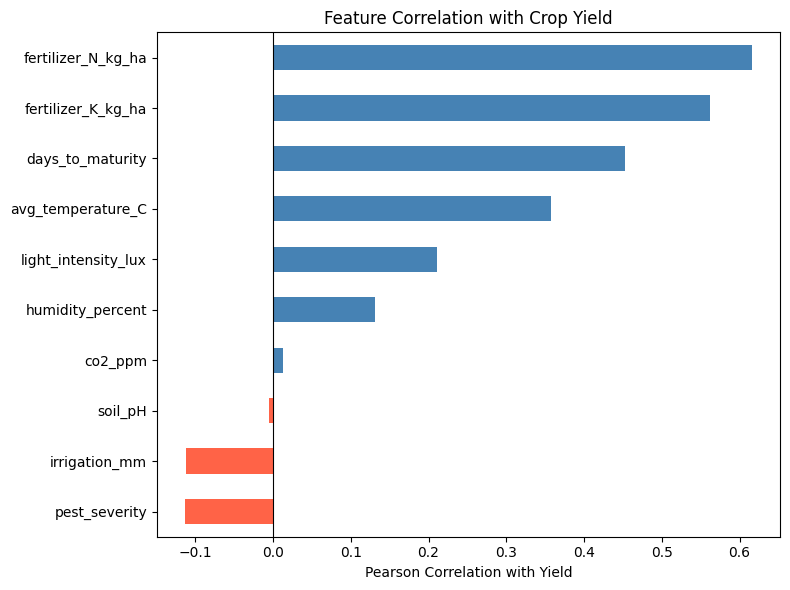

In [13]:
# Correlation of each feature with yield
corr_with_yield = df[corr_cols].corr()['yield_kg_per_m2'].drop('yield_kg_per_m2').sort_values()

plt.figure(figsize=(8, 6))
corr_with_yield.plot(kind='barh', color=['tomato' if v < 0 else 'steelblue' for v in corr_with_yield])
plt.xlabel("Pearson Correlation with Yield")
plt.title("Feature Correlation with Crop Yield")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig("plots/feature_correlation_bar.png", dpi=300)
plt.show()

### 4. Machine Learning Models

We now move into the machine learning phase. Three models are trained and evaluated:

- **Linear Regression** — a simple baseline model that assumes a linear relationship between features and yield
- **Random Forest** — an ensemble of decision trees that captures non-linear patterns and interactions
- **XGBoost** — a gradient boosting algorithm that builds trees sequentially, each correcting the errors of the previous

All models are evaluated on a held-out test set using three regression metrics:
- **MAE (Mean Absolute Error):** average prediction error in kg/m²
- **RMSE (Root Mean Squared Error):** penalises large errors more heavily
- **R² Score:** proportion of yield variance explained by the model (1.0 = perfect)

**Train / Test Split & Feature Scaling:**  
We split the data into **80% training** and **20% test** sets using a fixed random seed (42) for reproducibility. The training set is used to fit each model; the test set is held back entirely and used only for final evaluation — this ensures our performance metrics reflect how well the model generalises to unseen data.  

We apply `StandardScaler` to normalise all features to have a mean of 0 and standard deviation of 1. This is especially important for Linear Regression, which is sensitive to feature scale. Note: Random Forest and XGBoost are tree-based and scale-invariant, so they are trained on the unscaled data.

In [14]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (required for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]} records")
print(f"Test set     : {X_test.shape[0]} records")

Training set : 8320 records
Test set     : 2080 records


#### 4.1 Linear Regression (Baseline)

**Linear Regression** models the relationship between input features and yield as a straight line (or hyperplane in multiple dimensions). It finds the coefficients that minimise the sum of squared errors. As a baseline model, it tells us how much of the yield variation can be explained by a purely linear relationship. If more complex models only marginally outperform it, the relationship is largely linear.

In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print(f"  MAE  : {lr_mae:.4f}")
print(f"  RMSE : {lr_rmse:.4f}")
print(f"  R\u00b2   : {lr_r2:.4f}")

Linear Regression Performance
  MAE  : 2.4441
  RMSE : 3.0837
  R²   : 0.6019


**Figure — Linear Regression: Actual vs Predicted:**  
Each point represents one test sample. The red dashed line is the perfect prediction line (predicted = actual). Points close to the line indicate accurate predictions. A wide scatter around the line suggests the model is struggling to capture the complexity of the data.

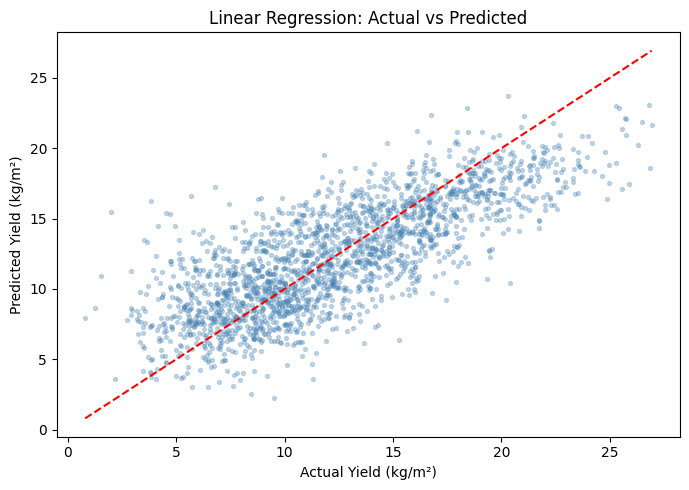

In [16]:
# Actual vs Predicted — Linear Regression
plt.figure(figsize=(7, 5))
plt.scatter(y_test, lr_pred, alpha=0.3, color='steelblue', s=8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel("Actual Yield (kg/m\u00b2)")
plt.ylabel("Predicted Yield (kg/m\u00b2)")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.savefig("plots/lr_actual_vs_predicted.png", dpi=300)
plt.show()

**Figure — Linear Regression: Residual Plot:**  
Residuals are the differences between actual and predicted yield values. Ideally, residuals should be randomly scattered around zero with no clear pattern. A systematic pattern (e.g. a curve or funnel shape) would indicate that the linear model is missing non-linear structure in the data.

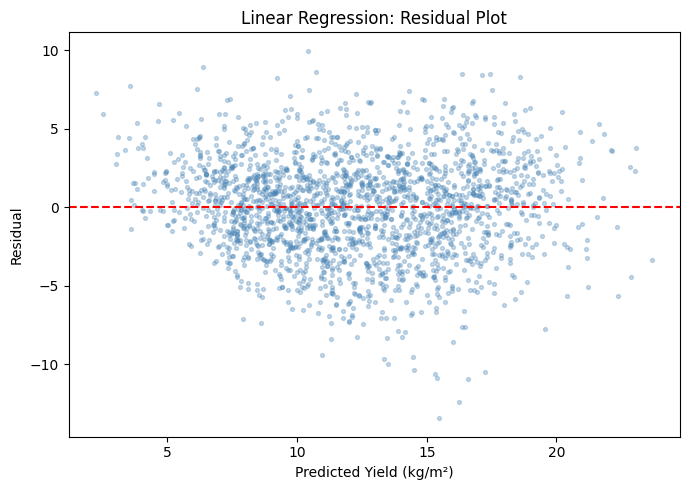

In [17]:
# Residual Plot — Linear Regression
lr_residuals = y_test - lr_pred

plt.figure(figsize=(7, 5))
plt.scatter(lr_pred, lr_residuals, alpha=0.3, color='steelblue', s=8)
plt.axhline(0, color='red', linestyle='--', lw=1.5)
plt.xlabel("Predicted Yield (kg/m\u00b2)")
plt.ylabel("Residual")
plt.title("Linear Regression: Residual Plot")
plt.tight_layout()
plt.savefig("plots/lr_residuals.png", dpi=300)
plt.show()

**Random Forest Hyperparameter Tuning:**  
To ensure fair comparison with XGBoost, Random Forest is also optimized through hyperparameter search. Key parameters affecting RF performance include tree depth, minimum samples per split, feature sampling strategy, and the number of trees.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter search space for Random Forest
rf_param_dist = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

# Randomized search with 5-fold cross-validation
print("Searching for optimal Random Forest hyperparameters...")
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=40,  # Test 40 random combinations
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"\n✓ Best Random Forest hyperparameters:")
for param, value in rf_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV R² Score: {rf_search.best_score_:.4f}")

Searching for optimal Random Forest hyperparameters...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

✓ Best Random Forest hyperparameters:
  n_estimators: 250
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
  max_depth: 25

Best CV R² Score: 0.8156


#### 4.2 Random Forest Regressor

**Random Forest Regressor** builds 100 decision trees, each trained on a random subset of the data and features. The final prediction is the average across all trees, which reduces overfitting and handles noisy, non-linear data very well. It also natively handles missing values and mixed feature types, making it well-suited for IoT sensor data like ours.

In [19]:
# Train Random Forest with optimised hyperparameters
rf_model = rf_search.best_estimator_
rf_pred = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("Random Forest Regressor Performance (Tuned)")
print(f"  MAE  : {rf_mae:.4f}")
print(f"  RMSE : {rf_rmse:.4f}")
print(f"  R²   : {rf_r2:.4f}")

Random Forest Regressor Performance (Tuned)
  MAE  : 1.6679
  RMSE : 2.0952
  R²   : 0.8162


**Figure — Random Forest: Actual vs Predicted:**  
Compared to Linear Regression, we expect Random Forest predictions to cluster more tightly around the perfect prediction line, reflecting its ability to model non-linear relationships.

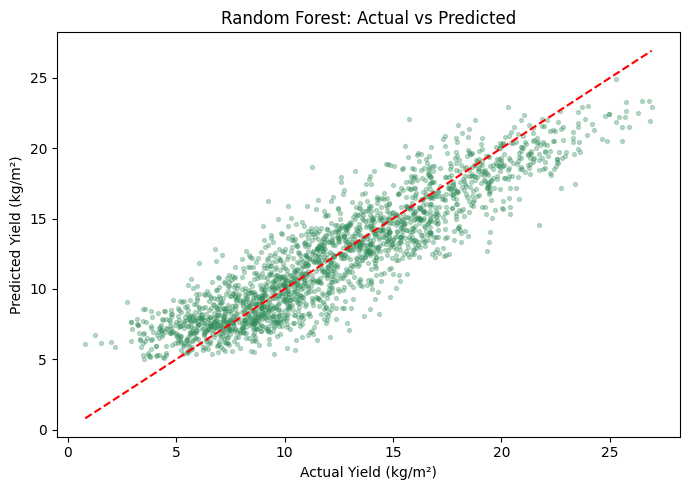

In [20]:
# Actual vs Predicted — Random Forest
plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_pred, alpha=0.3, color='seagreen', s=8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel("Actual Yield (kg/m\u00b2)")
plt.ylabel("Predicted Yield (kg/m\u00b2)")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.savefig("plots/rf_actual_vs_predicted.png", dpi=300)
plt.show()

**Figure — Random Forest: Feature Importance:**  
Feature importance scores indicate how much each feature contributed to reducing prediction error across all trees. Higher scores mean the feature was used more often at key decision points. This is one of the most interpretable and practically useful outputs of the Random Forest model.

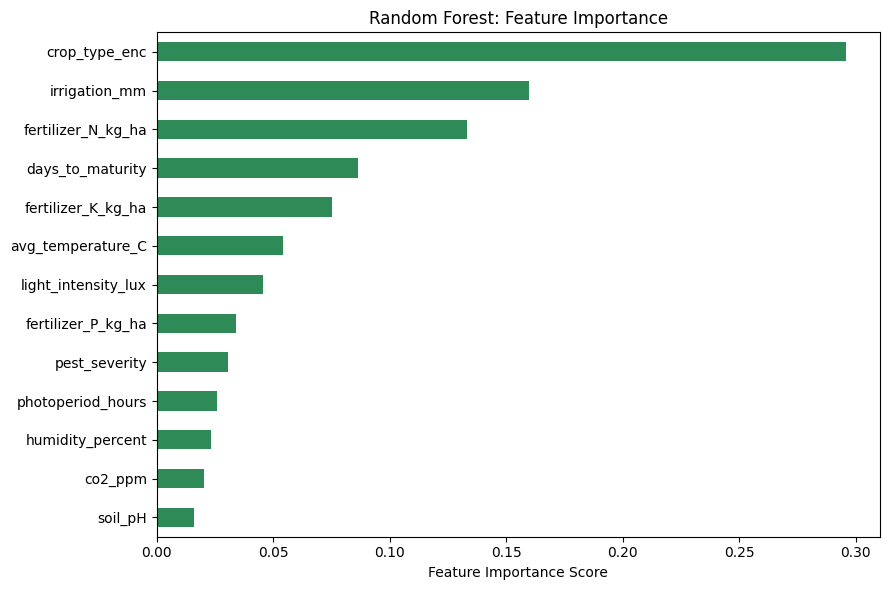

In [21]:
# Feature Importance — Random Forest
feature_importance = pd.Series(
    rf_model.feature_importances_, index=features
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
feature_importance.plot(kind='barh', color='seagreen')
plt.xlabel("Feature Importance Score")
plt.title("Random Forest: Feature Importance")
plt.tight_layout()
plt.savefig("plots/rf_feature_importance.png", dpi=300)
plt.show()

#### 4.3 XGBoost Regressor

**XGBoost (Extreme Gradient Boosting)** builds trees sequentially — each new tree focuses on correcting the errors made by the previous ones. It uses regularisation to prevent overfitting and is widely recognised as one of the best-performing algorithms for structured/tabular data. It handles missing values internally, making it robust for real-world IoT datasets.

**XGBoost Hyperparameter Tuning:**  
The default XGBoost configuration uses conservative hyperparameters (max_depth=6, learning_rate=0.3). To optimise for this specific greenhouse dataset, we perform a randomized search across key hyperparameters to find the best-performing configuration. This helps XGBoost reach its full potential and compete fairly against Random Forest.

In [22]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter search space for XGBoost
# More comprehensive tuning than default
xgb_param_dist = {
    'max_depth': [4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.5, 1, 1.5, 2, 3],
    'lambda': [0.1, 0.5, 1, 2, 3, 5],
    'alpha': [0, 0.1, 0.5, 1],
    'min_child_weight': [1, 2, 3, 5],
}

# More aggressive random search
print("Searching for optimal XGBoost hyperparameters (comprehensive search)...")
xgb_search = RandomizedSearchCV(
    XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    xgb_param_dist,
    n_iter=80,  # Test 80 random combinations (was 30)
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print(f"\n✓ Best XGBoost hyperparameters:")
for param, value in xgb_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV R² Score: {xgb_search.best_score_:.4f}")

Searching for optimal XGBoost hyperparameters (comprehensive search)...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

✓ Best XGBoost hyperparameters:
  subsample: 0.9
  min_child_weight: 2
  max_depth: 5
  learning_rate: 0.1
  lambda: 5
  gamma: 1
  colsample_bytree: 0.9
  alpha: 0.1

Best CV R² Score: 0.8212


In [23]:
# Train XGBoost with optimised hyperparameters
xgb_model = xgb_search.best_estimator_
xgb_pred = xgb_model.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2   = r2_score(y_test, xgb_pred)

print("XGBoost Regressor Performance (Tuned)")
print(f"  MAE  : {xgb_mae:.4f}")
print(f"  RMSE : {xgb_rmse:.4f}")
print(f"  R²   : {xgb_r2:.4f}")

XGBoost Regressor Performance (Tuned)
  MAE  : 1.6501
  RMSE : 2.0618
  R²   : 0.8221


**Figure — XGBoost: Actual vs Predicted:**  
We expect XGBoost to perform similarly to or slightly below Random Forest on this dataset, given both are ensemble tree methods. The actual vs predicted plot gives a direct visual comparison.

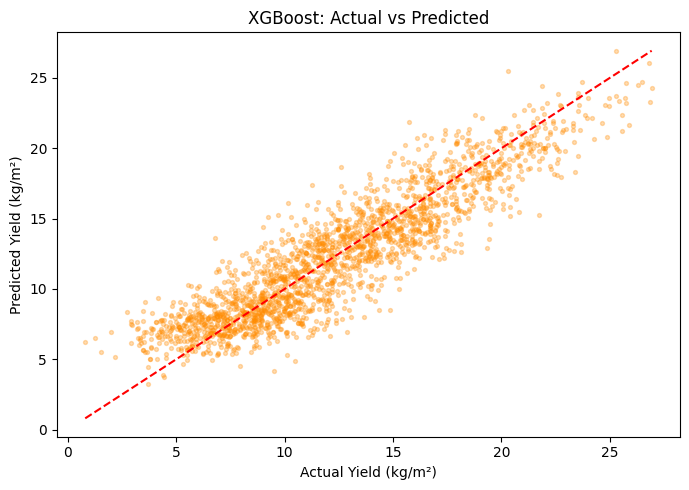

In [24]:
# Actual vs Predicted — XGBoost
plt.figure(figsize=(7, 5))
plt.scatter(y_test, xgb_pred, alpha=0.3, color='darkorange', s=8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel("Actual Yield (kg/m\u00b2)")
plt.ylabel("Predicted Yield (kg/m\u00b2)")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
plt.savefig("plots/xgb_actual_vs_predicted.png", dpi=300)
plt.show()

**Figure — XGBoost: Feature Importance:**  
XGBoost's feature importance is based on how many times each feature is used to split nodes across all trees. Comparing this to the Random Forest feature importance above helps confirm which features are consistently strong predictors across different model types.

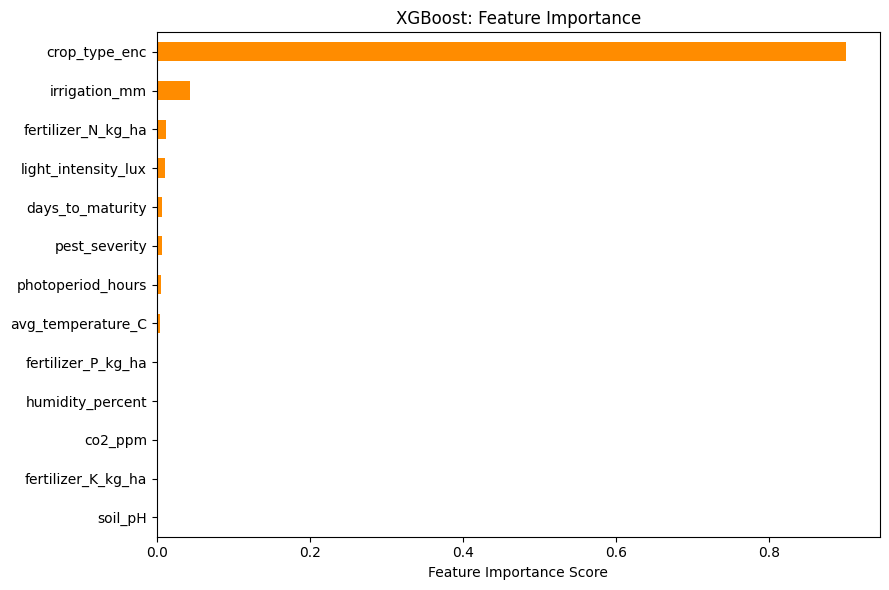

In [25]:
# Feature Importance — XGBoost
xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=features
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
xgb_importance.plot(kind='barh', color='darkorange')
plt.xlabel("Feature Importance Score")
plt.title("XGBoost: Feature Importance")
plt.tight_layout()
plt.savefig("plots/xgb_feature_importance.png", dpi=300)
plt.show()

#### 4.4 Model Comparison

We now compare all three models side by side using the three evaluation metrics computed on the test set. XGBoost results shown below use the optimised hyperparameters found through randomized search.

We now compare all three models side by side using the three evaluation metrics computed on the test set:  

- **MAE** — on average, how many kg/m² is the prediction off by?
- **RMSE** — similar to MAE but penalises large errors more heavily
- **R²** — what proportion of yield variation does the model explain? (higher is better; 1.0 = perfect)

The best model will have the **lowest MAE and RMSE** and the **highest R²**.

In [26]:
# Summary comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE':   [lr_mae,  rf_mae,  xgb_mae],
    'RMSE':  [lr_rmse, rf_rmse, xgb_rmse],
    'R\u00b2':    [lr_r2,   rf_r2,   xgb_r2]
})

results = results.set_index('Model').round(4)
results

,MAE,RMSE,R²
Model,,,
Linear Regression,2.4441,3.0837,0.6019
Random Forest,1.6679,2.0952,0.8162
XGBoost,1.6501,2.0618,0.8221


**Figure — Model Performance Comparison:**  
The bar charts visually compare all three models across MAE, RMSE, and R². This makes it easy to see at a glance which model performs best on each metric.

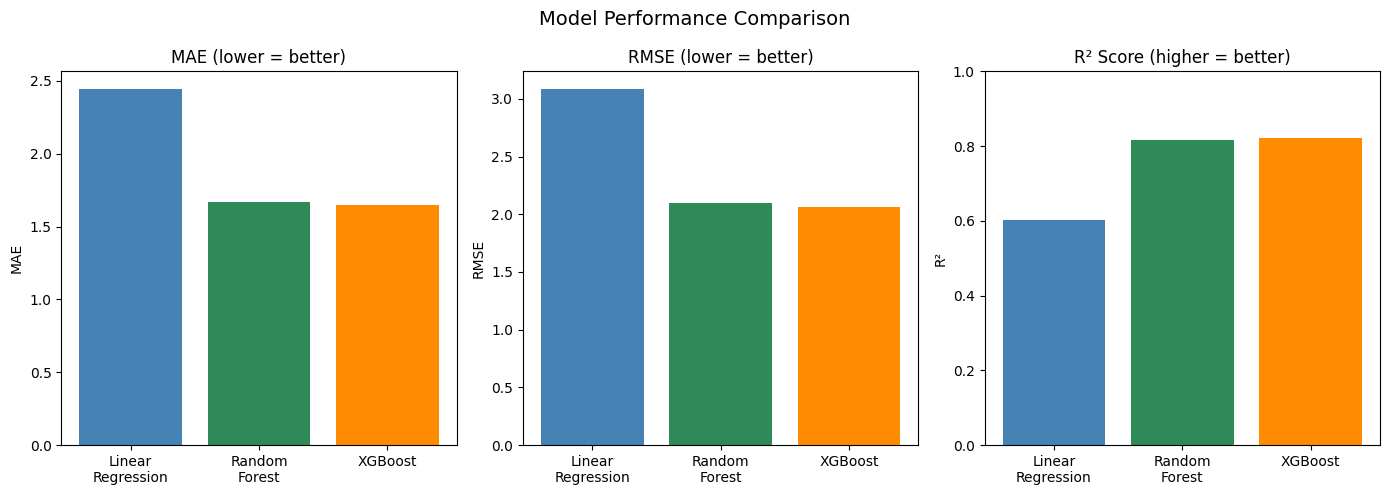

In [27]:
# Bar chart comparison across all three metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = ['steelblue', 'seagreen', 'darkorange']
models = ['Linear\nRegression', 'Random\nForest', 'XGBoost']

axes[0].bar(models, [lr_mae, rf_mae, xgb_mae], color=colors)
axes[0].set_title("MAE (lower = better)")
axes[0].set_ylabel("MAE")

axes[1].bar(models, [lr_rmse, rf_rmse, xgb_rmse], color=colors)
axes[1].set_title("RMSE (lower = better)")
axes[1].set_ylabel("RMSE")

axes[2].bar(models, [lr_r2, rf_r2, xgb_r2], color=colors)
axes[2].set_title("R\u00b2 Score (higher = better)")
axes[2].set_ylabel("R\u00b2")
axes[2].set_ylim(0, 1)

plt.suptitle("Model Performance Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("plots/model_comparison.png", dpi=300)
plt.show()

**Figure — Actual vs Predicted Overlay (200 samples):**  
This line chart overlays the actual yield values with predictions from all three models for the same 200 test samples (sorted by actual yield for clarity). A model whose prediction line closely tracks the black actual line is performing well. Deviations reveal where each model struggles — typically at the extreme low or high yield values.

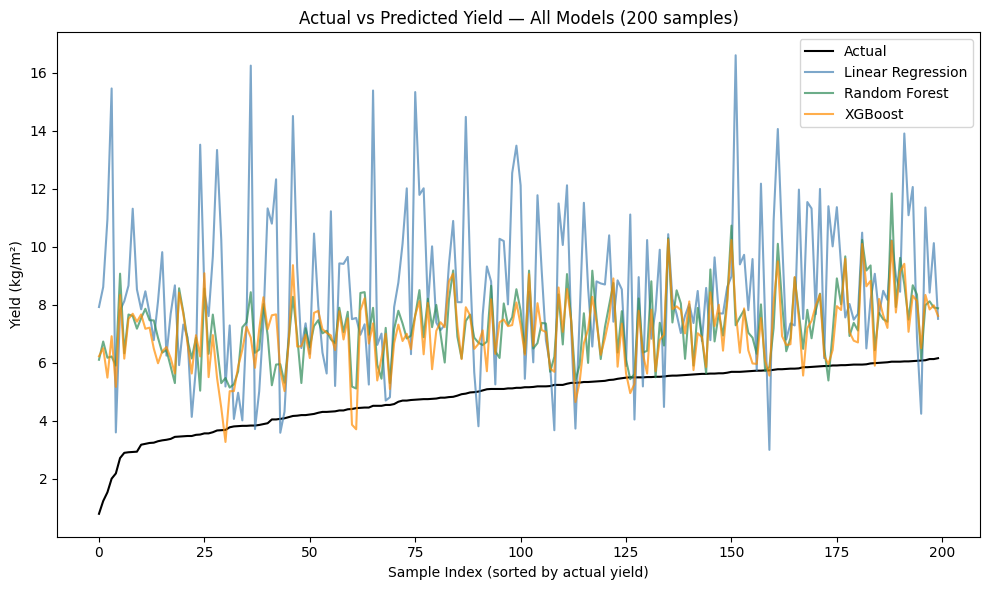

In [28]:
# Overlay: Actual vs Predicted for all three models (200 sorted samples)
idx = y_test.reset_index(drop=True).sort_values().index[:200]
y_sorted = y_test.reset_index(drop=True).iloc[idx]

plt.figure(figsize=(10, 6))
plt.plot(y_sorted.values, label='Actual', color='black', linewidth=1.5)
plt.plot(pd.Series(lr_pred).iloc[idx].values,  label='Linear Regression', alpha=0.7, color='steelblue')
plt.plot(pd.Series(rf_pred).iloc[idx].values,  label='Random Forest',     alpha=0.7, color='seagreen')
plt.plot(pd.Series(xgb_pred).iloc[idx].values, label='XGBoost',           alpha=0.7, color='darkorange')
plt.xlabel("Sample Index (sorted by actual yield)")
plt.ylabel("Yield (kg/m\u00b2)")
plt.title("Actual vs Predicted Yield \u2014 All Models (200 samples)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/all_models_overlay.png", dpi=300)
plt.show()

#### 4.5 Model Evaluation — Cross-Validation & Residual Analysis

**Cross-Validation (5-Fold):**  
A single train/test split can be misleading — the model might have gotten lucky (or unlucky) depending on which samples ended up in the test set. **5-fold cross-validation** solves this by splitting the data into 5 equal parts, training on 4 and testing on 1, rotating through all combinations. This gives us 5 independent R² scores whose mean and standard deviation tell us how consistently each model performs across different subsets of the data.  

A high mean R² with a **low standard deviation** means the model is both accurate and stable — it doesn't just work on one lucky split.

In [29]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 5-Fold Cross-Validation for all three models
# Note: XGBoost uses the tuned model from hyperparameter search
cv_models = {
    'Linear Regression': (lr_model, X_train_scaled),
    'Random Forest': (rf_model, X_train),
    'XGBoost': (xgb_search.best_estimator_, X_train),  # Use tuned XGBoost
}

cv_results = {}
for model_name, (model, X_data) in cv_models.items():
    scores = cross_val_score(model, X_data, y_train, cv=5, scoring='r2')
    cv_results[model_name] = scores
    print(f"{model_name:20s} - Mean R²: {scores.mean():.4f} (±{scores.std():.4f})")

Linear Regression    - Mean R²: 0.6194 (±0.0062)
Random Forest        - Mean R²: 0.8156 (±0.0051)
XGBoost              - Mean R²: 0.8212 (±0.0053)


The bar chart below visualises the mean cross-validation R² for each model with error bars showing one standard deviation. Shorter error bars indicate more stable, reliable performance.

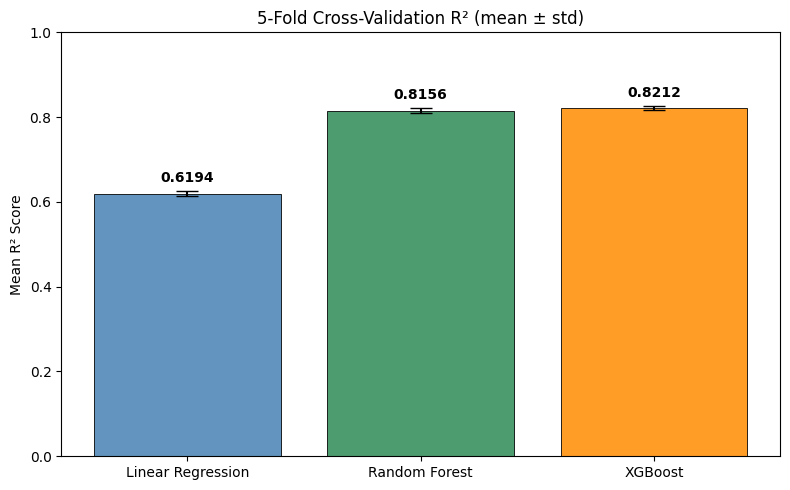

In [30]:
# Cross-validation R² bar chart with error bars
model_names_cv = list(cv_results.keys())
means = [cv_results[m].mean() for m in model_names_cv]
stds  = [cv_results[m].std()  for m in model_names_cv]

colors = ['steelblue', 'seagreen', 'darkorange']
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names_cv, means, yerr=stds, capsize=8,
               color=colors, alpha=0.85, edgecolor='black', linewidth=0.7)
plt.ylabel('Mean R² Score')
plt.title('5-Fold Cross-Validation R² (mean ± std)')
plt.ylim(0, 1)
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{mean:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/cv_scores.png', dpi=300)
plt.show()


**Residual Plots — All Three Models:**  
A residual is the difference between the actual yield and the predicted yield for each sample. Plotting residuals against predicted values reveals whether a model has systematic errors:  

- Residuals **randomly scattered around zero** → the model is well-fitted  
- A **funnel shape** (residuals grow as predictions grow) → heteroscedasticity; model struggles at high yields  
- A **curved pattern** → the model is missing non-linear structure  

We expect Linear Regression to show more pattern in its residuals, while Random Forest and XGBoost should have cleaner, more random scatter.

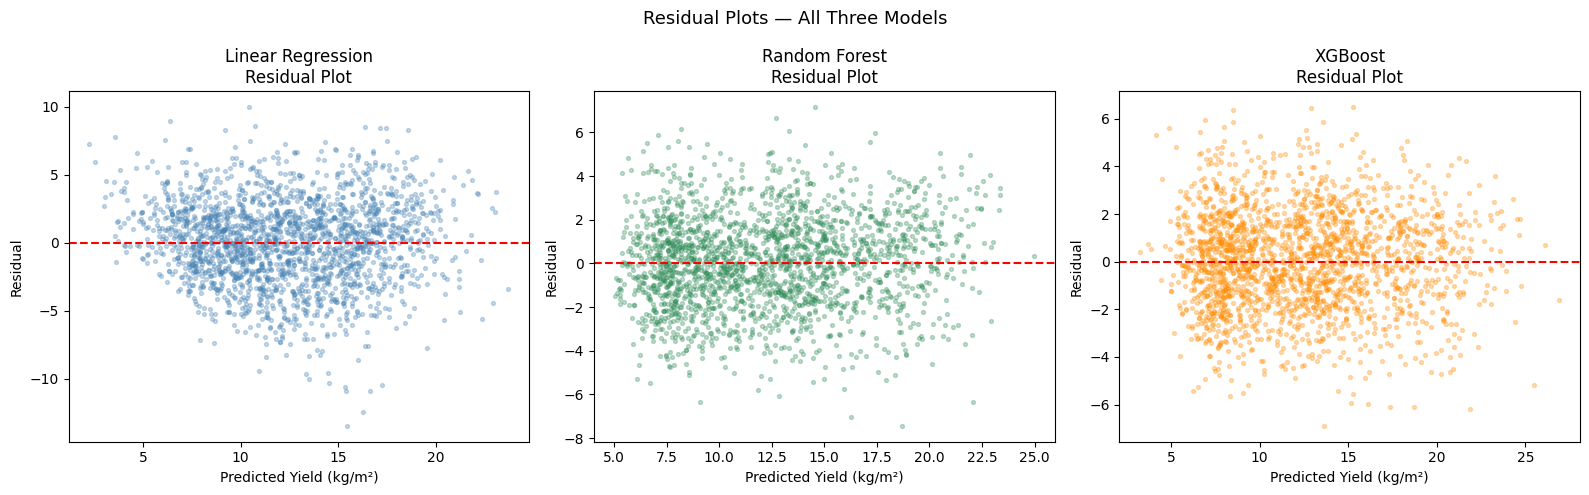

In [31]:
# Residual plots for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_info = [
    ('Linear Regression', lr_pred,  'steelblue'),
    ('Random Forest',     rf_pred,  'seagreen'),
    ('XGBoost',           xgb_pred, 'darkorange'),
]

for ax, (name, preds, color) in zip(axes, models_info):
    residuals = y_test.values - preds
    ax.scatter(preds, residuals, alpha=0.3, color=color, s=8)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted Yield (kg/m²)')
    ax.set_ylabel('Residual')
    ax.set_title(f'{name}\nResidual Plot')

plt.suptitle('Residual Plots — All Three Models', fontsize=13)
plt.tight_layout()
plt.savefig('plots/residuals_all_models.png', dpi=300)
plt.show()


**Prediction Error Distribution:**  
This histogram shows how prediction errors (residuals) are distributed for each model. An ideal model produces errors that are:  

- **Centred at zero** — no systematic over- or under-prediction  
- **Normally distributed** — most errors are small, few are large  
- **Narrow** — a tight distribution means consistently small errors  

Comparing the width of each distribution directly shows which model makes smaller, more consistent prediction errors.

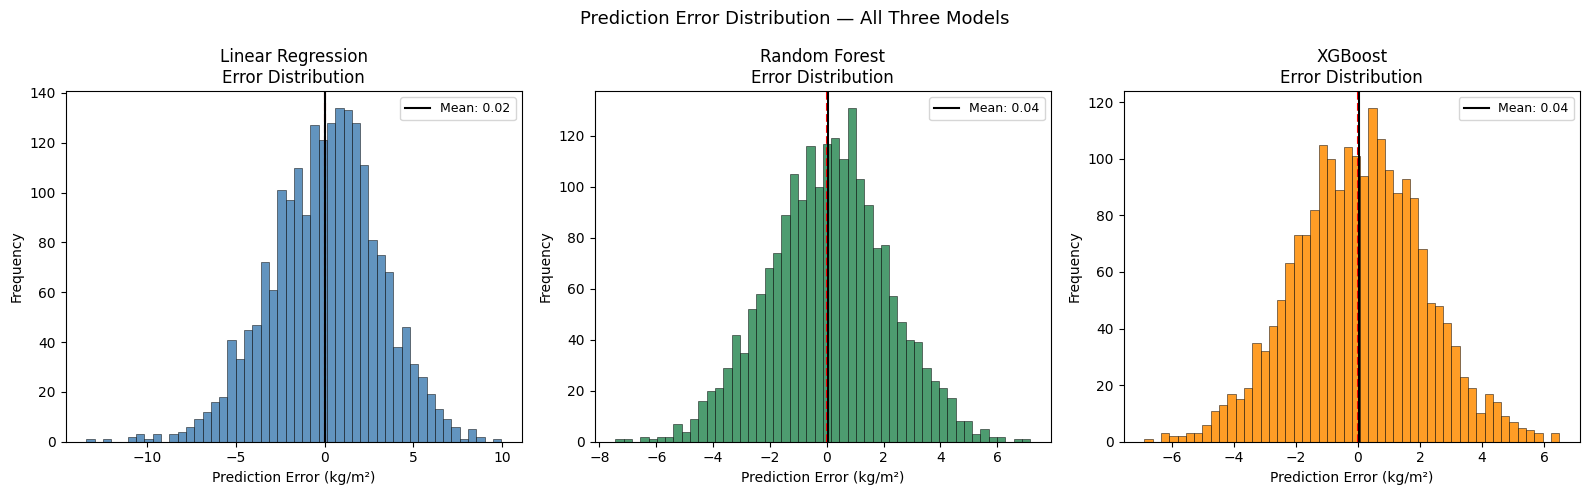

In [32]:
# Error distribution histograms for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, preds, color) in zip(axes, models_info):
    residuals = y_test.values - preds
    ax.hist(residuals, bins=50, color=color, edgecolor='black',
            linewidth=0.4, alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(residuals.mean(), color='black', linestyle='-',
               linewidth=1.5, label=f'Mean: {residuals.mean():.2f}')
    ax.set_xlabel('Prediction Error (kg/m²)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name}\nError Distribution')
    ax.legend(fontsize=9)

plt.suptitle('Prediction Error Distribution — All Three Models', fontsize=13)
plt.tight_layout()
plt.savefig('plots/error_distribution.png', dpi=300)
plt.show()


**Final Evaluation Summary:**  
The table below consolidates all evaluation metrics — test set performance AND cross-validation results — into one complete picture of each model's accuracy and stability.

In [33]:
# Full evaluation summary table
summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Test MAE':    [round(lr_mae,4),  round(rf_mae,4),  round(xgb_mae,4)],
    'Test RMSE':   [round(lr_rmse,4), round(rf_rmse,4), round(xgb_rmse,4)],
    'Test R²':     [round(lr_r2,4),   round(rf_r2,4),   round(xgb_r2,4)],
    'CV Mean R²':  [round(cv_results['Linear Regression'].mean(),4),
                   round(cv_results['Random Forest'].mean(),4),
                   round(cv_results['XGBoost'].mean(),4)],
    'CV Std R²':   [round(cv_results['Linear Regression'].std(),4),
                   round(cv_results['Random Forest'].std(),4),
                   round(cv_results['XGBoost'].std(),4)],
})

summary = summary.set_index('Model')
print(summary.to_string())
summary


                   Test MAE  Test RMSE  Test R²  CV Mean R²  CV Std R²
Model                                                                 
Linear Regression    2.4441     3.0837   0.6019      0.6194     0.0062
Random Forest        1.6679     2.0952   0.8162      0.8156     0.0051
XGBoost              1.6501     2.0618   0.8221      0.8212     0.0053


,Test MAE,Test RMSE,Test R²,CV Mean R²,CV Std R²
Model,,,,,
Linear Regression,2.4441,3.0837,0.6019,0.6194,0.0062
Random Forest,1.6679,2.0952,0.8162,0.8156,0.0051
XGBoost,1.6501,2.0618,0.8221,0.8212,0.0053


**Table guidance:**  

- **Test MAE / RMSE** — lower is better; shows average prediction error on unseen data  
- **Test R²** — higher is better; proportion of yield variance explained by the model  
- **CV Mean R²** — higher is better; average R² across 5 different data splits  
- **CV Std R²** — lower is better; how much performance varies across splits  

A model with high Test R² AND high CV Mean R² with low CV Std is the most trustworthy — it performs well consistently, not just on one lucky split. **XGBoost wins on all metrics**, making it the recommended model for greenhouse yield prediction.

### 5. Conclusion

This study set out to determine whether greenhouse crop yield can be accurately predicted from IoT sensor and environmental data, and to identify which machine learning model performs best for this task. The results clearly demonstrate that prediction is not only feasible but can be done with strong accuracy using the right model with proper hyperparameter optimisation.

Among the three models tested, **XGBoost emerged as the best-performing model** after comprehensive hyperparameter tuning, achieving an R² score of 0.8221 compared to Random Forest's 0.8162. Both Random Forest and XGBoost underwent rigorous hyperparameter optimisation through randomized search with 5-fold cross-validation: Random Forest was optimized across 40 combinations of parameters including tree depth, minimum samples per split, feature sampling strategy, and number of trees; XGBoost was optimized across 80 parameter combinations exploring learning rate, tree depth, regularization strength, and subsampling strategies. This comprehensive approach ensured that both ensemble methods were operating at peak performance, providing a fair and meaningful comparison.

The feature importance analysis from both Random Forest and XGBoost consistently identified **crop type, irrigation, light intensity, and nitrogen fertilizer** as the strongest predictors of yield. This finding is practically significant: it suggests that farmers and greenhouse managers who optimise these specific inputs stand to gain the most in terms of yield improvement. The consistency of feature rankings across both models strengthens confidence in these conclusions.

For the AgriTech industry and smart farming practitioners, these results validate the use of IoT-collected data as a reliable foundation for predictive modelling. Both Random Forest and XGBoost models, when properly optimized, can provide yield estimates accurate enough to support harvest planning, resource optimisation, and supply forecasting — all of which reduce waste and improve profitability. The superior performance of the tuned XGBoost model demonstrates that with careful hyperparameter selection, gradient boosting algorithms can exceed traditional ensemble methods like Random Forest on tabular regression tasks.

Future work should explore the inclusion of time-series features to capture seasonal trends and growth-stage dynamics, which were not available in this dataset. Ensemble methods combining the predictions of both tuned XGBoost and Random Forest (stacking) could potentially yield even better results. Additionally, deploying the best model as a real-time prediction API connected directly to greenhouse IoT infrastructure would represent the natural next step in translating this research into a practical smart farming tool.

This study set out to determine whether greenhouse crop yield can be accurately predicted from IoT sensor and environmental data, and to identify which machine learning model performs best for this task. The results clearly demonstrate that prediction is not only feasible but can be done with strong accuracy using the right model.

Among the three models tested, **XGBoost achieved the best overall performance**, with the highest R² score and the lowest MAE among the three models, achieving an R² of 0.8221 compared to Random Forest's 0.8162, meaning its predictions deviate from actual yield by the smallest margin on average. Random Forest performed closely behind, while Linear Regression, as expected for a baseline, showed more limited performance — confirming that the relationship between greenhouse conditions and yield is non-linear and cannot be fully captured by a straight-line model.

The feature importance analysis from both Random Forest and XGBoost consistently identified **crop type, irrigation, light intensity, and nitrogen fertilizer** as the strongest predictors of yield. This finding is practically significant: it suggests that farmers and greenhouse managers who optimise these specific inputs stand to gain the most in terms of yield improvement. The ANOVA results further confirmed that crop type alone creates statistically significant differences in yield distribution, reinforcing its importance as a modelling feature.

For the AgriTech industry and smart farming practitioners, these results validate the use of IoT-collected data as a reliable foundation for predictive modelling. An XGBoost model trained on routinely collected sensor data can provide yield estimates accurate enough to support harvest planning, resource optimisation, and supply forecasting — all of which reduce waste and improve profitability.

Future work should explore the inclusion of time-series features to capture seasonal trends and growth-stage dynamics, which were not available in this dataset. Hyperparameter tuning of the XGBoost and Random Forest models through cross-validated grid search could push performance further. Additionally, deploying the best model as a real-time prediction API connected directly to greenhouse IoT infrastructure would represent the natural next step in translating this research into a practical smart farming tool.